# 06 — Classical machine learning baselines

**Input:** `data/processed/btc_features.csv` (from notebook 05)
**Goal:** establish *honest* classical baselines for next-day direction before any deep learning. The EDA and statistical notebooks already warned us: direction is near-random, so the bar to clear isn't 90% — it's the **majority-class** and **persistence** baselines. A model that can't beat those is worthless, and saying so is the point.

Models: Logistic Regression, Random Forest, XGBoost. Everything uses a strict **chronological** 70/15/15 split (no shuffling — that would leak the future), and the scaler is fit on **train only**.

In [1]:
import sys
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             confusion_matrix, roc_curve)
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="06_classical_ml"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)

df=pd.read_csv(paths.PROCESSED_FILE.parent/"btc_features.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
feat_cols=[c for c in df.columns if c not in ("date","target_return","target_direction")]
print(len(df),"rows,",len(feat_cols),"features")

4189 rows, 24 features


## Chronological split + scaling

Train = oldest 70%, validation = next 15%, test = most recent 15%. The test set is the *future* relative to training — exactly how the model will be used. Scaler learns mean/std from train only, then transforms val/test, so no test information leaks backward.

In [2]:
n=len(df); i_tr=int(n*0.70); i_va=int(n*0.85)
tr,va,te=df.iloc[:i_tr],df.iloc[i_tr:i_va],df.iloc[i_va:]
print(f"train {tr.date.min().date()}–{tr.date.max().date()} ({len(tr)})")
print(f"val   {va.date.min().date()}–{va.date.max().date()} ({len(va)})")
print(f"test  {te.date.min().date()}–{te.date.max().date()} ({len(te)})")

scaler=StandardScaler().fit(tr[feat_cols])
Xtr,Xva,Xte=[scaler.transform(d[feat_cols]) for d in (tr,va,te)]
ytr,yva,yte=tr["target_direction"].values,va["target_direction"].values,te["target_direction"].values

train 2014-12-18–2023-01-05 (2932)
val   2023-01-06–2024-09-24 (628)
test  2024-09-25–2026-06-15 (629)


## Baselines first — the bar to beat

Two dumb predictors. If a real model can't beat both, it has no edge.
- **Majority class:** always predict the more common class in train.
- **Persistence:** predict tomorrow goes the same direction as yesterday's return.

In [3]:
maj=int(round(ytr.mean()))
acc_majority=accuracy_score(yte,np.full_like(yte,maj))
# persistence: sign of yesterday's return -> ret_lag1 > 0 means yesterday up
persist_pred=(te["ret_lag1"].values>0).astype(int)
acc_persist=accuracy_score(yte,persist_pred)
print(f"Majority-class accuracy : {acc_majority:.4f}")
print(f"Persistence accuracy    : {acc_persist:.4f}")
baseline=max(acc_majority,acc_persist)
print(f"=> Bar to beat: {baseline:.4f}")

Majority-class accuracy : 0.4960
Persistence accuracy    : 0.4849
=> Bar to beat: 0.4960


## The three models

In [4]:
models={
 "LogReg":LogisticRegression(max_iter=1000,C=0.5),
 "RandomForest":RandomForestClassifier(n_estimators=300,max_depth=4,min_samples_leaf=20,random_state=0),
 "XGBoost":XGBClassifier(n_estimators=200,max_depth=3,learning_rate=0.03,
                         subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=0),
}
rows=[]; probs={}
for name,m in models.items():
    m.fit(Xtr,ytr)
    p=m.predict_proba(Xte)[:,1]; pred=(p>0.5).astype(int)
    probs[name]=p
    rows.append({"model":name,"accuracy":accuracy_score(yte,pred),
                 "AUC":roc_auc_score(yte,p),"F1":f1_score(yte,pred)})
res=pd.DataFrame(rows)
res=pd.concat([res,pd.DataFrame([{"model":"Majority","accuracy":acc_majority,"AUC":0.5,"F1":np.nan},
                                 {"model":"Persistence","accuracy":acc_persist,"AUC":np.nan,"F1":np.nan}])],ignore_index=True)
res.round(4).to_csv(TAB/"model_metrics.csv",index=False); res.round(4)

,model,accuracy,AUC,F1
0,LogReg,0.4960,0.4955,0.6318
1,RandomForest,0.5167,0.4947,0.6228
2,XGBoost,0.5024,0.5150,0.5250
3,Majority,0.4960,0.5000,NaN
4,Persistence,0.4849,NaN,NaN


## Honest read

Expect test accuracy in the low-to-mid 50s and AUC barely above 0.5 — consistent with everything the statistics told us. If any model showed 0.9+, I'd hunt for leakage immediately (a feature computed using same-day or future information). The features here are all strictly lagged/rolling on *past* data, with the target being *next*-day direction, so there's no same-day leakage by construction.

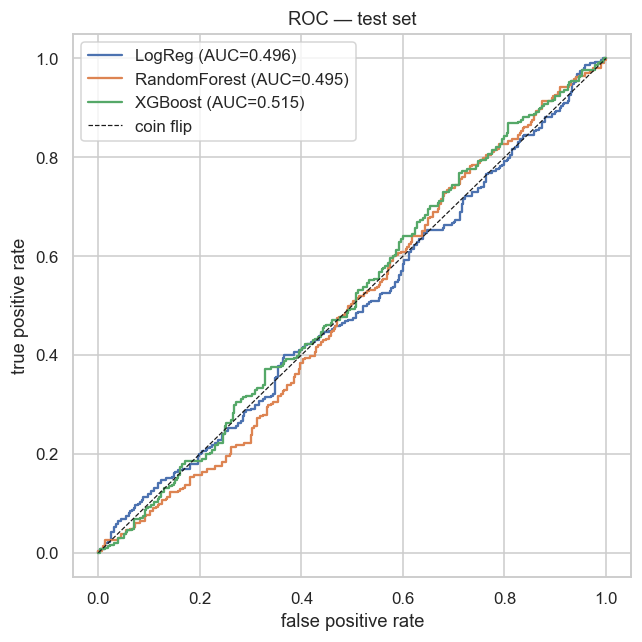

In [5]:
# ROC curves
fig,ax=plt.subplots(figsize=(6,6))
for name,p in probs.items():
    fpr,tpr,_=roc_curve(yte,p); ax.plot(fpr,tpr,lw=1.5,label=f"{name} (AUC={roc_auc_score(yte,p):.3f})")
ax.plot([0,1],[0,1],"k--",lw=0.8,label="coin flip")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC — test set"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"roc_curves.png",bbox_inches="tight"); plt.show()

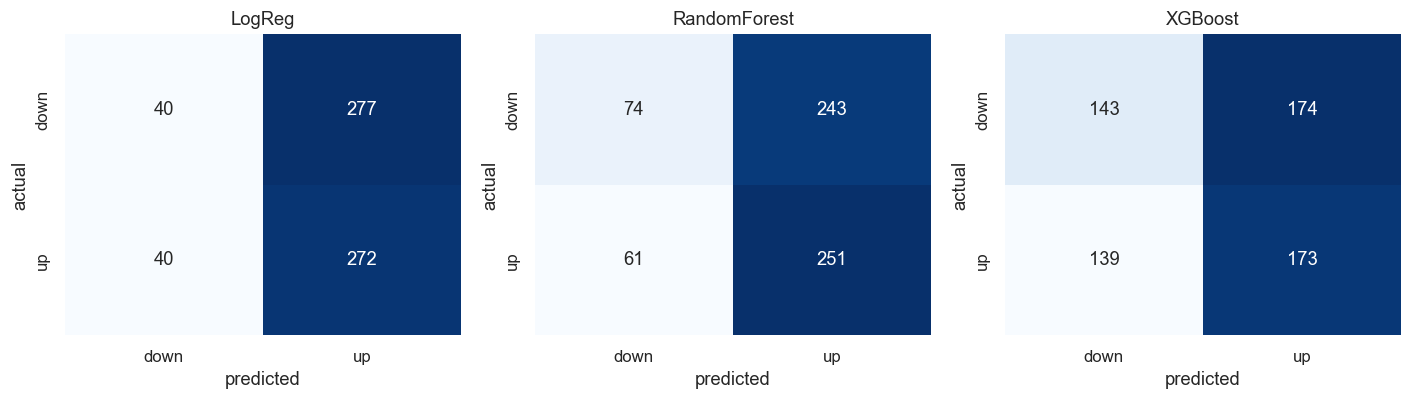

In [6]:
# Confusion matrices
fig,axes=plt.subplots(1,3,figsize=(13,3.8))
for ax,(name,p) in zip(axes,probs.items()):
    cm=confusion_matrix(yte,(p>0.5).astype(int))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,ax=ax,
                xticklabels=["down","up"],yticklabels=["down","up"])
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("actual")
fig.tight_layout(); fig.savefig(FIG/"confusion_matrices.png",bbox_inches="tight"); plt.show()

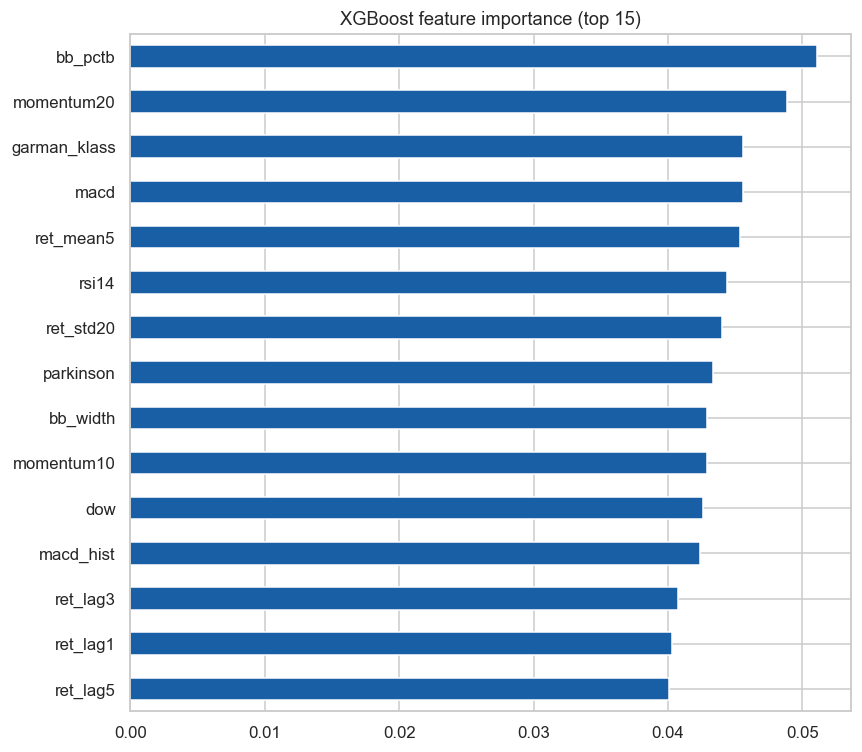

In [7]:
# Feature importance (XGBoost)
imp=pd.Series(models["XGBoost"].feature_importances_,index=feat_cols).sort_values(ascending=True)
fig,ax=plt.subplots(figsize=(8,7))
imp.tail(15).plot.barh(ax=ax,color="#185FA5")
ax.set_title("XGBoost feature importance (top 15)")
fig.tight_layout(); fig.savefig(FIG/"feature_importance.png",bbox_inches="tight"); plt.show()
imp.sort_values(ascending=False).to_csv(TAB/"feature_importance.csv")

In [8]:
# Save test-set predictions for notebook 09 (model comparison)
preds=pd.DataFrame({"date":te["date"].values,"y_true":yte})
for name,p in probs.items():
    preds[f"prob_{name}"]=p; preds[f"pred_{name}"]=(p>0.5).astype(int)
preds.to_csv(paths.PROCESSED_FILE.parent/"predictions_classical.csv",index=False)
print("Saved predictions_classical.csv:",preds.shape)

Saved predictions_classical.csv: (629, 8)


## Takeaway

The classical bar is set. Best of these models is the number deep learning has to beat in notebook 07 — and given the data, "beat" might mean a fraction of a percent, or nothing at all. That comparison, done honestly, is the actual contribution.